# Task 2: Predicting customer buying behaviour

* Explore and prepare the dataset
  - explore the datasets to understand the different columns considering how to prepare the data for a predictive model.
* Train a machine learning model
  - train a machine learning model to be able to predict the target outcome, by using RandomForest.
* Evaluate the model and present findings
  - evaluate how well it performed by conducting cross-validation and outputting appropriate evaluation metrics.


## Exploratory Data Analysis

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
# read data from customer_book.csv and check the data

df = pd.read_csv('customer_booking.csv', encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [94]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [95]:
# check the class balance
df['booking_complete'].value_counts()

,count
booking_complete,
0,42522
1,7478


There is a significant class imbalance toward incomplete bookings.

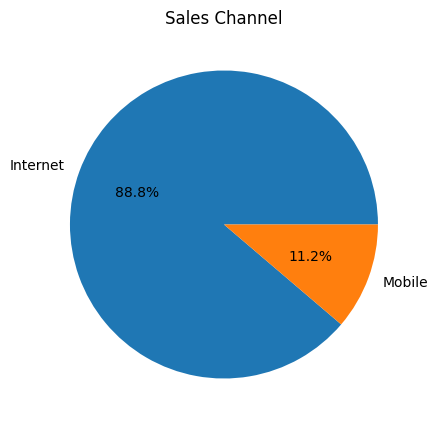

In [96]:
plt.figure(figsize=(5,5))
plt.pie(df['sales_channel'].value_counts(), labels=df['sales_channel'].value_counts().index, autopct='%1.1f%%')
plt.title('Sales Channel')
plt.show()

Most of the bookings are done through internet.

In [97]:
df['trip_type'].value_counts(normalize=True) * 100

,proportion
trip_type,
RoundTrip,98.994
OneWay,0.774
CircleTrip,0.232


RoundTrip is overwhelmingly the dominant trip type.

<Axes: xlabel='purchase_lead', ylabel='Count'>

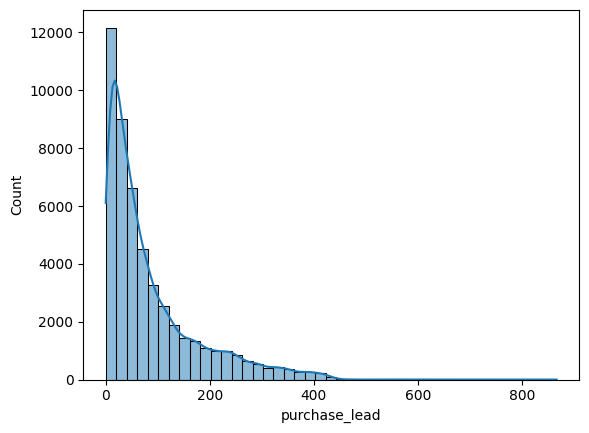

In [98]:
sns.histplot(data=df, x='purchase_lead', binwidth=20, kde=True)

There is a long right tail, indicating skewness. Booking a flight over a year in advance is rare in real-world scenarios. Therefore, we assume that no customer is booking in advance of more than one and half year and we will remove all entries with purchase_lead more than 500 days.

In [99]:
df = df[df['purchase_lead'] < 500]
df.shape

(49982, 14)

<Axes: xlabel='length_of_stay', ylabel='Count'>

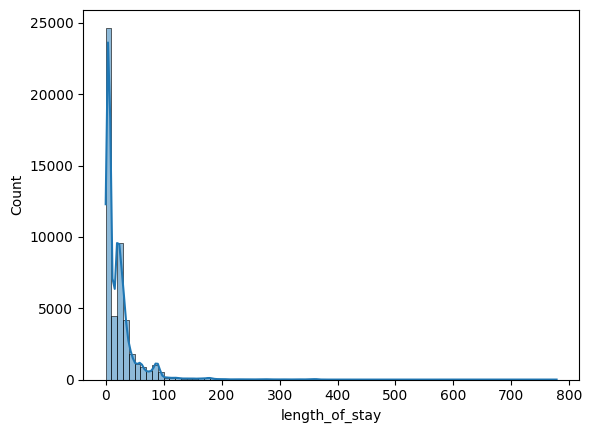

In [100]:
sns.histplot(data=df, x="length_of_stay", binwidth=10, kde=True)

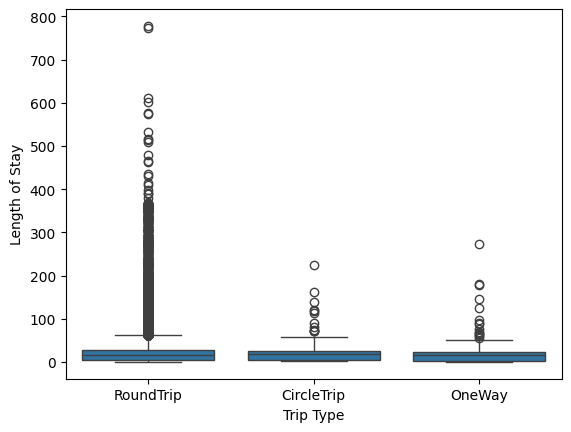

In [101]:
sns.boxplot(x='trip_type', y='length_of_stay', data=df)
plt.xlabel('Trip Type')
plt.ylabel('Length of Stay')
plt.show()

We will focus on Round Trip tickets done for length of stay less than 500 days.

In [102]:
df = df[df['length_of_stay'] < 500]
df.shape

(49972, 14)

<Axes: xlabel='flight_day'>

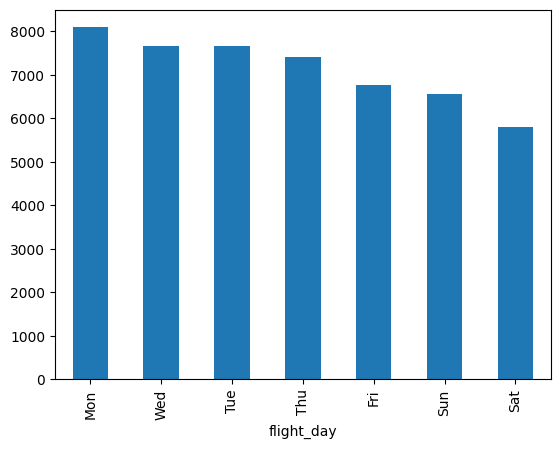

In [103]:
df['flight_day'].value_counts().plot(kind='bar')

Customers tend to travel more on weekdays than on weekends.

Text(0, 0.5, 'Number of complete bookings')

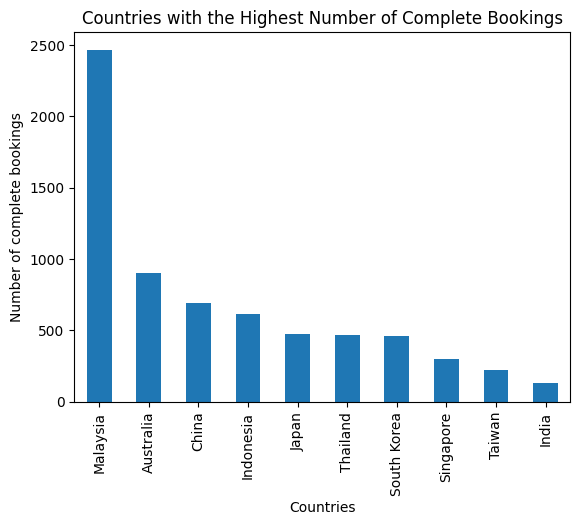

In [104]:
df[df.booking_complete ==1].booking_origin.value_counts()[:10].plot(kind="bar")
plt.title("Countries with the Highest Number of Complete Bookings")
plt.xlabel("Countries")
plt.ylabel("Number of complete bookings")

Text(0, 0.5, 'Number of incomplete bookings')

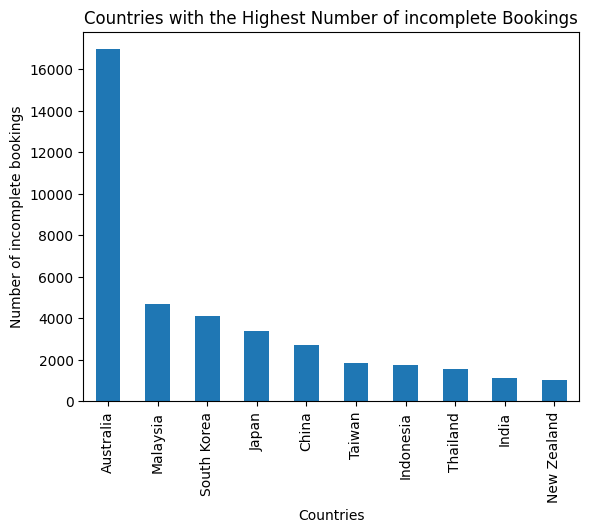

In [105]:
df[df.booking_complete ==0].booking_origin.value_counts()[:10].plot(kind="bar")
plt.title("Countries with the Highest Number of incomplete Bookings")
plt.xlabel("Countries")
plt.ylabel("Number of incomplete bookings")

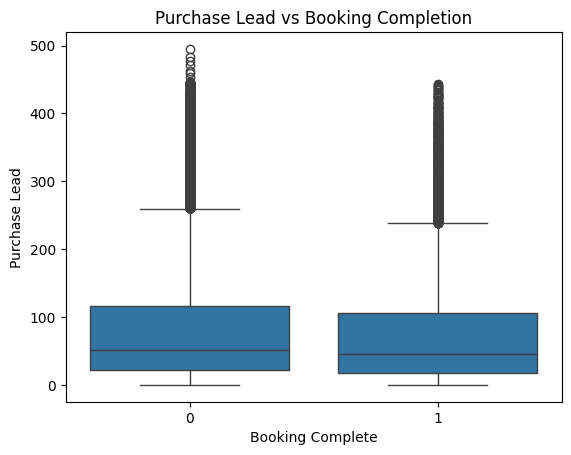

In [43]:
sns.boxplot(x='booking_complete', y='purchase_lead', data=df)
plt.title('Purchase Lead vs Booking Completion')
plt.xlabel('Booking Complete')
plt.ylabel('Purchase Lead')
plt.show()

We assume that customers who completed their bookings had a slightly lower purchase lead time.

In [44]:
pd.crosstab(df['wants_extra_baggage'], df['booking_complete'], normalize='index') * 100

booking_complete,0,1
wants_extra_baggage,,
0,88.499426,11.500574
1,83.329843,16.670157


## Convert Categorical Variables

In [45]:
df.select_dtypes(include='object').columns

Index(['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin'], dtype='object')

In [46]:
# apply one-hot encoding to sales_channel, and trip_type
df = pd.get_dummies(df, columns=['sales_channel', 'trip_type'])
df.head()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,sales_channel_Internet,sales_channel_Mobile,trip_type_CircleTrip,trip_type_OneWay,trip_type_RoundTrip
0,2,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0,True,False,False,False,True
1,1,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0,True,False,False,False,True
2,2,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0,True,False,False,False,True
3,1,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0,True,False,False,False,True
4,2,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0,True,False,False,False,True


In [47]:
# apply label encoding to flight_day
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)
df.head()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,sales_channel_Internet,sales_channel_Mobile,trip_type_CircleTrip,trip_type_OneWay,trip_type_RoundTrip
0,2,262,19,7,6,AKLDEL,New Zealand,1,0,0,5.52,0,True,False,False,False,True
1,1,112,20,3,6,AKLDEL,New Zealand,0,0,0,5.52,0,True,False,False,False,True
2,2,243,22,17,3,AKLDEL,India,1,1,0,5.52,0,True,False,False,False,True
3,1,96,31,4,6,AKLDEL,New Zealand,0,0,1,5.52,0,True,False,False,False,True
4,2,68,22,15,3,AKLDEL,India,1,0,1,5.52,0,True,False,False,False,True


In [13]:
df['route'].value_counts(normalize=True) * 100

,proportion
route,
AKLKUL,5.357000
PENTPE,1.849035
MELSGN,1.684944
ICNSIN,1.602898
DMKKIX,1.488834
...,...
HKTJED,0.002001
KBRWUH,0.002001
KTMTWU,0.002001


In [14]:
df['booking_origin'].value_counts(normalize=True)

,proportion
booking_origin,
Australia,0.357380
Malaysia,0.143520
South Korea,0.091231
Japan,0.077724
China,0.067778
...,...
Ghana,0.000020
Gibraltar,0.000020
Guatemala,0.000020


Since there are too many unique categories for route and booking_origin, we will remove these features.

In [49]:
df.drop(['route','booking_origin'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49972 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   num_passengers          49972 non-null  int64  
 1   purchase_lead           49972 non-null  int64  
 2   length_of_stay          49972 non-null  int64  
 3   flight_hour             49972 non-null  int64  
 4   flight_day              49972 non-null  int64  
 5   wants_extra_baggage     49972 non-null  int64  
 6   wants_preferred_seat    49972 non-null  int64  
 7   wants_in_flight_meals   49972 non-null  int64  
 8   flight_duration         49972 non-null  float64
 9   booking_complete        49972 non-null  int64  
 10  sales_channel_Internet  49972 non-null  bool   
 11  sales_channel_Mobile    49972 non-null  bool   
 12  trip_type_CircleTrip    49972 non-null  bool   
 13  trip_type_OneWay        49972 non-null  bool   
 14  trip_type_RoundTrip     49972 non-null  boo

## Correlation matrix

In [50]:
df.corr(numeric_only=True)['booking_complete'].sort_values(ascending=False)

,booking_complete
booking_complete,1.000000
wants_extra_baggage,0.068213
wants_preferred_seat,0.050205
sales_channel_Internet,0.041024
trip_type_RoundTrip,0.028239
wants_in_flight_meals,0.026460
num_passengers,0.024015
flight_hour,0.007283
flight_day,-0.006955
trip_type_CircleTrip,-0.014401


### Train/Test split

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X = df.loc[:, df.columns != 'booking_complete']
y = df['booking_complete']

In [53]:
print(X.shape)
print(y.shape)

(49972, 14)
(49972,)


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Random Forest Classifier

In [55]:
from sklearn.ensemble import RandomForestClassifier

# fit the model
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [64]:
# make prediction
y_pred = model.predict(X_test)

In [65]:
from sklearn.metrics import precision_score, recall_score, f1_score

#calculate precision, recall, F1
print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"F1: {f1_score(y_test, y_pred)}")

Precision: 0.45098039215686275
Recall: 0.06125166444740346
F1: 0.10785463071512309


In [67]:
from sklearn.metrics import classification_report

#generate classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8493
           1       0.45      0.06      0.11      1502

    accuracy                           0.85      9995
   macro avg       0.65      0.52      0.51      9995
weighted avg       0.80      0.85      0.80      9995



Text(0.5, 0, 'Feature Importance of Random Forest ')

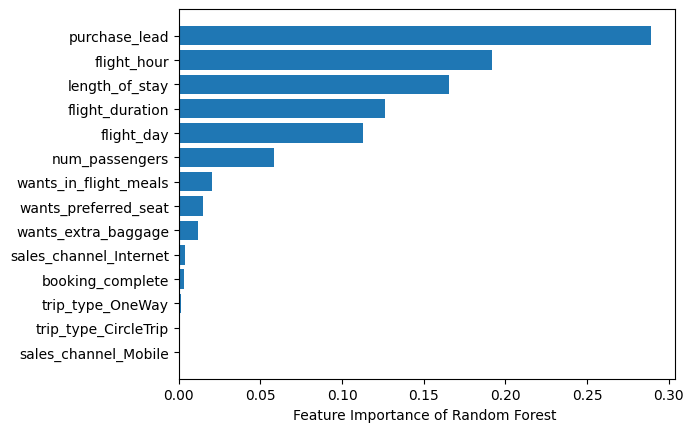

In [69]:
sorted_idx = model.feature_importances_.argsort()
plt.barh(df.iloc[:,:-1].columns[sorted_idx], model.feature_importances_[sorted_idx])
plt.xlabel("Feature Importance of Random Forest ")

Since we have significantly more instances labelled as 0 compared to those labeled as 1, a key reason for the low F1 score is the imbalanced dataset.

Therefore, to address the issue of imbalanced dataset, we will apply a oversampling method: SMOTE.

 ### Use SMOTE

In [83]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

model = RandomForestClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [86]:
y_pred = model.predict(X_test)

print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"F1: {f1_score(y_test, y_pred)}")

print(classification_report(y_test, y_pred))

Precision: 0.8789161727349704
Recall: 0.8505208942994265
F1: 0.8644854253420583
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      8456
           1       0.88      0.85      0.86      8543

    accuracy                           0.87     16999
   macro avg       0.87      0.87      0.87     16999
weighted avg       0.87      0.87      0.87     16999



Text(0.5, 0, 'Feature Importance of Random Forest ')

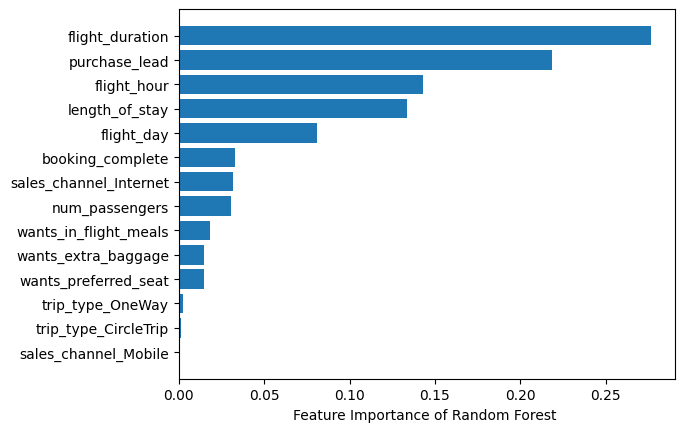

In [89]:
sorted_idx = model.feature_importances_.argsort()
plt.barh(df.iloc[:,:-1].columns[sorted_idx], model.feature_importances_[sorted_idx])
plt.xlabel("Feature Importance of Random Forest ")